# Aftenposten Content Analysis — Plots & Analysis

**Research Question:** Did the Stoltenberg appointment reprime the 2025
Norwegian election around security and competence?

Three observation periods:

- **BEFORE** — ~2 weeks before Stoltenberg appointment (mid-Jan to Feb 3, 2025)
- **AFTER** — ~2 weeks after appointment (Feb 5 to ~Feb 20, 2025)
- **ELECTION** — ~2 weeks before election day (late Aug to Sep 8, 2025)


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import warnings

warnings.filterwarnings("ignore")

# =============================================================================
# LOAD CLEANED DATA
# =============================================================================
OUTPUT_DIR = Path("../data/output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Load the CSV produced by parse_aftenposten.py
CSV_PATH = OUTPUT_DIR / "aftenposten_all_articles.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["date"])
print(f"Loaded {len(df)} articles from {CSV_PATH}")

# If the period column wasn't computed with the ELECTION window, recompute it
# --- Adjust these dates to match your actual data ---
TREATMENT_DATE = pd.Timestamp("2025-02-04")
BEFORE_START = pd.Timestamp("2025-01-13")
BEFORE_END = pd.Timestamp("2025-02-03")
AFTER_START = pd.Timestamp("2025-02-05")
AFTER_END = pd.Timestamp("2025-02-21")
ELECT_START = pd.Timestamp("2025-08-18")
ELECT_END = pd.Timestamp("2025-09-08")


def assign_period(d):
    if pd.isna(d):
        return "UNKNOWN"
    if BEFORE_START <= d <= BEFORE_END:
        return "BEFORE"
    if AFTER_START <= d <= AFTER_END:
        return "AFTER"
    if ELECT_START <= d <= ELECT_END:
        return "ELECTION"
    if d == TREATMENT_DATE:
        return "TREATMENT_DAY"
    return "OUTSIDE"


df["period"] = df["date"].apply(assign_period)

# Issue groups
ISSUE_GROUPS = {
    "FrP-owned": ["IMM", "ECON"],
    "Labour-owned": ["SEC", "GOV"],
    "Contested": ["TAX"],
    "Left-niche": ["CLI", "GAZ", "HEA"],
    "Other": ["OTH"],
}
CODE_TO_GROUP = {}
for g, codes in ISSUE_GROUPS.items():
    for c in codes:
        CODE_TO_GROUP[c] = g
df["issue_group"] = df["issue_code"].map(CODE_TO_GROUP).fillna("Other")

# Boolean flags (ensure they exist)
for col in ["mentions_stoltenberg", "mentions_listhaug", "mentions_solberg"]:
    if col in df.columns:
        flag = "flag_" + col.replace("mentions_", "")
        df[flag] = df[col].astype(str).str.upper() == "YES"

# Build analysis sample: only the three periods, only Norway-related
PERIOD_ORDER = ["BEFORE", "AFTER", "ELECTION"]
dfa = df[df["period"].isin(PERIOD_ORDER)].copy()

print(f"\nAnalysis sample: {len(dfa)} articles")
for p in PERIOD_ORDER:
    n = (dfa["period"] == p).sum()
    print(f"  {p}: {n}")

Loaded 821 articles from ../data/output/aftenposten_all_articles.csv

Analysis sample: 698 articles
  BEFORE: 248
  AFTER: 216
  ELECTION: 234


In [4]:
# =============================================================================
# SCIENCES PO STYLE
# =============================================================================
SCPO_RED = "#E6142D"
SCPO_DARKGREY = "#333333"
SCPO_MIDGREY = "#6B6B6B"
SCPO_LIGHTGREY = "#E8E8E8"
SCPO_OFFWHITE = "#F7F7F7"

PAL = {
    "red": "#E6142D",
    "blue_dark": "#1B3A5C",
    "blue": "#2E6B9E",
    "blue_light": "#6BAED6",
    "teal": "#3A9E8F",
    "orange": "#E8853A",
    "gold": "#D4A843",
    "grey": "#9E9E9E",
    "pink": "#D4707A",
}

PERIOD_COLORS = {"BEFORE": PAL["blue_dark"], "AFTER": SCPO_RED, "ELECTION": PAL["teal"]}
PERIOD_LABELS = {
    "BEFORE": "Before\n(Jan 2025)",
    "AFTER": "After Stoltenberg\n(Feb 2025)",
    "ELECTION": "Pre-election\n(Aug–Sep 2025)",
}

GROUP_COLORS = {
    "FrP-owned": "#C0392B",
    "Labour-owned": "#2E6B9E",
    "Contested": "#27AE60",
    "Left-niche": "#8E44AD",
    "Other": "#BDC3C7",
}

ISSUE_LABELS = {
    "IMM": "Immigration\n& Crime",
    "ECON": "Cost-of-living\n& Energy",
    "SEC": "Security\n& Defence",
    "GOV": "Governance\n& Leadership",
    "TAX": "Wealth tax\n& Inequality",
    "GAZ": "Gaza &\nSov. Fund",
    "CLI": "Climate\n& Oil",
    "HEA": "Health\n& Welfare",
    "OTH": "Other",
}

plt.rcParams.update(
    {
        "figure.facecolor": SCPO_OFFWHITE,
        "axes.facecolor": SCPO_OFFWHITE,
        "axes.edgecolor": SCPO_LIGHTGREY,
        "axes.labelcolor": SCPO_DARKGREY,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlecolor": SCPO_DARKGREY,
        "axes.labelsize": 11,
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": SCPO_LIGHTGREY,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.7,
        "xtick.color": SCPO_MIDGREY,
        "ytick.color": SCPO_MIDGREY,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "text.color": SCPO_DARKGREY,
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.facecolor": SCPO_OFFWHITE,
        "legend.frameon": False,
        "legend.fontsize": 9,
    }
)


def add_watermark(fig):
    fig.text(
        0.98,
        0.01,
        "Sciences Po — Democracy, Parties & Elections in Europe",
        ha="right",
        va="bottom",
        fontsize=6.5,
        color=SCPO_MIDGREY,
        style="italic",
        alpha=0.6,
    )


def add_source(ax, extra=""):
    txt = "Source: Author's coding of Aftenposten (Nyheter section), Jan–Sep 2025."
    if extra:
        txt += " " + extra
    ax.annotate(
        txt,
        xy=(0, -0.18),
        xycoords="axes fraction",
        fontsize=7,
        color=SCPO_MIDGREY,
        style="italic",
    )


In [5]:
# =============================================================================
# Precompute shared crosstabs
# =============================================================================
group_pct = (
    pd.crosstab(dfa["issue_group"], dfa["period"], normalize="columns")
    .reindex(columns=PERIOD_ORDER)
    .fillna(0)
    * 100
)

code_pct = (
    pd.crosstab(dfa["issue_code"], dfa["period"], normalize="columns")
    .reindex(columns=PERIOD_ORDER)
    .fillna(0)
    * 100
)

period_has_data = {p: (dfa["period"] == p).sum() > 0 for p in PERIOD_ORDER}

print("\nPrecomputed tables ready. Generating charts...\n")


Precomputed tables ready. Generating charts...



## Figure 1 — Issue Group Shift (grouped bars)


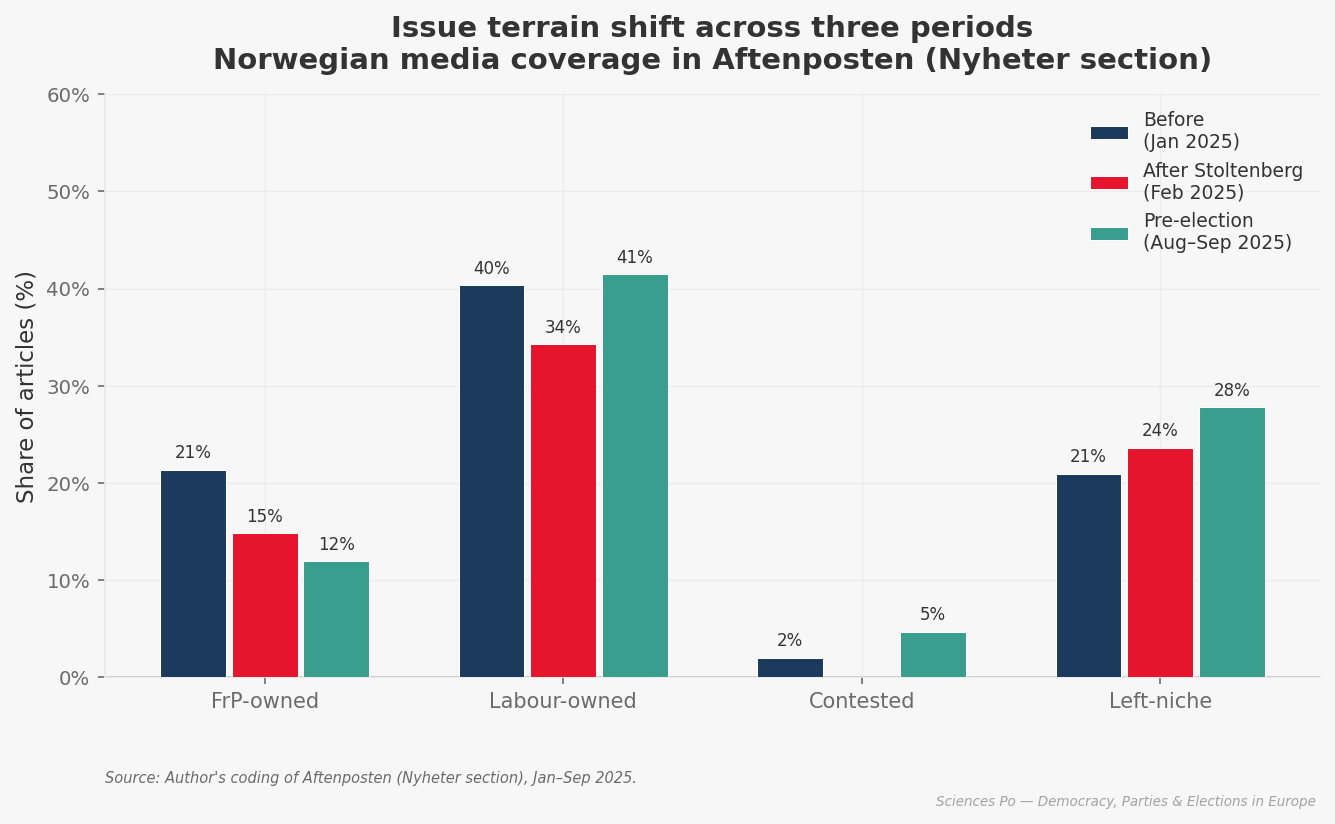

In [6]:
groups_show = ["FrP-owned", "Labour-owned", "Contested", "Left-niche"]
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(groups_show))
width = 0.24

for i, period in enumerate(PERIOD_ORDER):
    if not period_has_data[period]:
        continue
    vals = [
        group_pct.loc[g, period] if g in group_pct.index else 0 for g in groups_show
    ]
    bars = ax.bar(
        x + (i - 1) * width,
        vals,
        width * 0.92,
        label=PERIOD_LABELS[period],
        color=PERIOD_COLORS[period],
        edgecolor="white",
        linewidth=0.5,
        zorder=3,
    )
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.8,
                f"{h:.0f}%",
                ha="center",
                va="bottom",
                fontsize=8,
                color=SCPO_DARKGREY,
                fontweight="medium",
            )

ax.set_xticks(x)
ax.set_xticklabels(groups_show, fontsize=10)
ax.set_ylabel("Share of articles (%)")
ax.set_title(
    "Issue terrain shift across three periods\n"
    "Norwegian media coverage in Aftenposten (Nyheter section)",
    pad=12,
)
ax.set_ylim(0, max(group_pct.max().max() * 1.25, 60))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(loc="upper right")
ax.axhline(y=0, color=SCPO_DARKGREY, linewidth=0.8, zorder=1)
add_source(ax)
add_watermark(fig)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig1_issue_groups_by_period.png")
fig.savefig(OUTPUT_DIR / "fig1_issue_groups_by_period.pdf")
plt.show()


## Figure 2 — Issue Code Heatmap


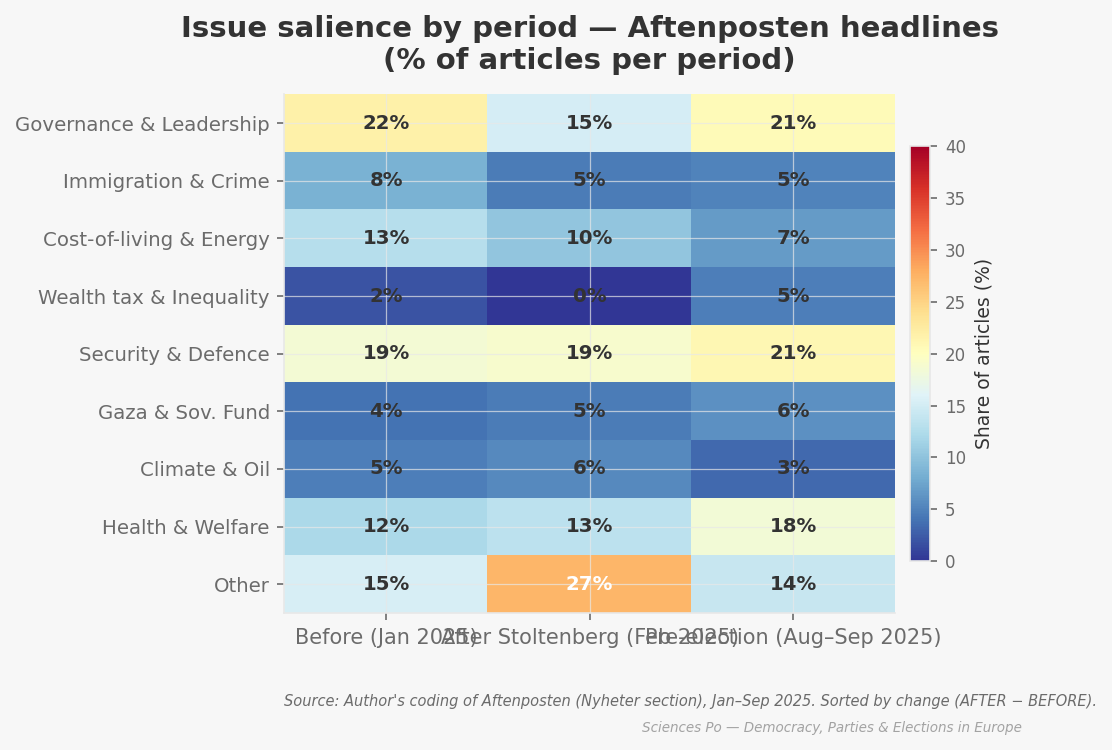

In [7]:
hm = code_pct.copy()
hm["change"] = hm.get("AFTER", 0) - hm.get("BEFORE", 0)
hm = hm.sort_values("change", ascending=True).drop(columns="change")

fig, ax = plt.subplots(figsize=(7, 5))
mat = hm.fillna(0).values
im = ax.imshow(
    mat, aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=max(np.nanmax(mat), 40)
)

ax.set_xticks(range(len(PERIOD_ORDER)))
ax.set_xticklabels(
    [PERIOD_LABELS[p].replace("\n", " ") for p in PERIOD_ORDER], fontsize=10
)
ax.set_yticks(range(len(hm.index)))
ax.set_yticklabels(
    [ISSUE_LABELS.get(c, c).replace("\n", " ") for c in hm.index], fontsize=9.5
)

for i in range(len(hm.index)):
    for j, p in enumerate(PERIOD_ORDER):
        v = mat[i, j]
        if not period_has_data[p]:
            ax.text(
                j, i, "—", ha="center", va="center", fontsize=9.5, color=SCPO_MIDGREY
            )
        else:
            ax.text(
                j,
                i,
                f"{v:.0f}%",
                ha="center",
                va="center",
                fontsize=9.5,
                fontweight="bold",
                color="white" if v > 25 else SCPO_DARKGREY,
            )

ax.set_title(
    "Issue salience by period — Aftenposten headlines\n(% of articles per period)",
    pad=12,
)
cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Share of articles (%)", fontsize=9)
cbar.ax.tick_params(labelsize=8)
add_source(ax, "Sorted by change (AFTER − BEFORE).")
add_watermark(fig)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig2_issue_heatmap.png")
fig.savefig(OUTPUT_DIR / "fig2_issue_heatmap.pdf")
plt.show()


## Figure 3 — Leader Visibility


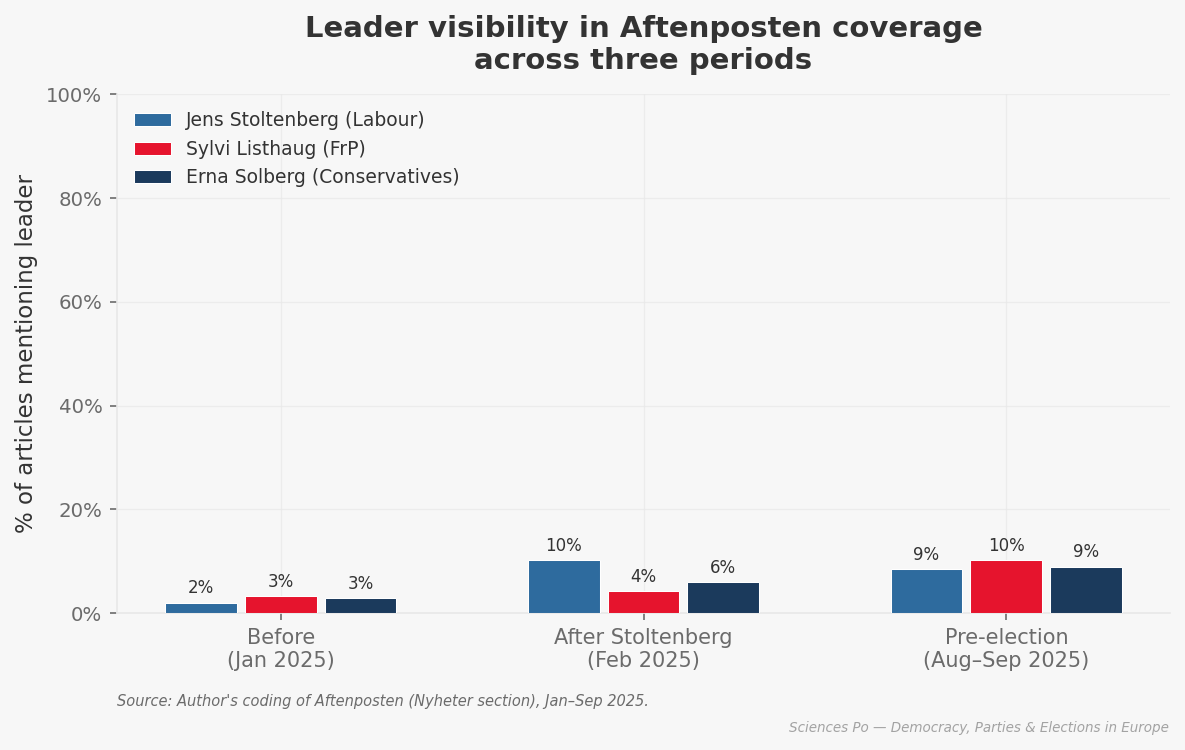

In [8]:
leaders = {
    "stoltenberg": ("Jens Stoltenberg (Labour)", PAL["blue"]),
    "listhaug": ("Sylvi Listhaug (FrP)", SCPO_RED),
    "solberg": ("Erna Solberg (Conservatives)", PAL["blue_dark"]),
}

leader_pct = {}
for period in PERIOD_ORDER:
    sub = dfa[dfa["period"] == period]
    n = len(sub)
    for ldr in leaders:
        col = f"flag_{ldr}"
        if col in sub.columns and n > 0:
            leader_pct.setdefault(ldr, {})[period] = sub[col].sum() / n * 100

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(PERIOD_ORDER))
width = 0.22

for i, (ldr, (label, color)) in enumerate(leaders.items()):
    vals = [leader_pct.get(ldr, {}).get(p, 0) for p in PERIOD_ORDER]
    bars = ax.bar(
        x + (i - 1) * width,
        vals,
        width * 0.9,
        label=label,
        color=color,
        edgecolor="white",
        linewidth=0.5,
        zorder=3,
    )
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f"{v:.0f}%",
                ha="center",
                va="bottom",
                fontsize=8,
                color=SCPO_DARKGREY,
                fontweight="medium",
            )

ax.set_xticks(x)
ax.set_xticklabels([PERIOD_LABELS[p] for p in PERIOD_ORDER], fontsize=10)
ax.set_ylabel("% of articles mentioning leader")
ax.set_title("Leader visibility in Aftenposten coverage\nacross three periods", pad=12)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(loc="upper left")
add_source(ax)
add_watermark(fig)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig3_leader_mentions.png")
fig.savefig(OUTPUT_DIR / "fig3_leader_mentions.pdf")
plt.show()


## Figure 4 — Tone toward Labour (stacked bars)


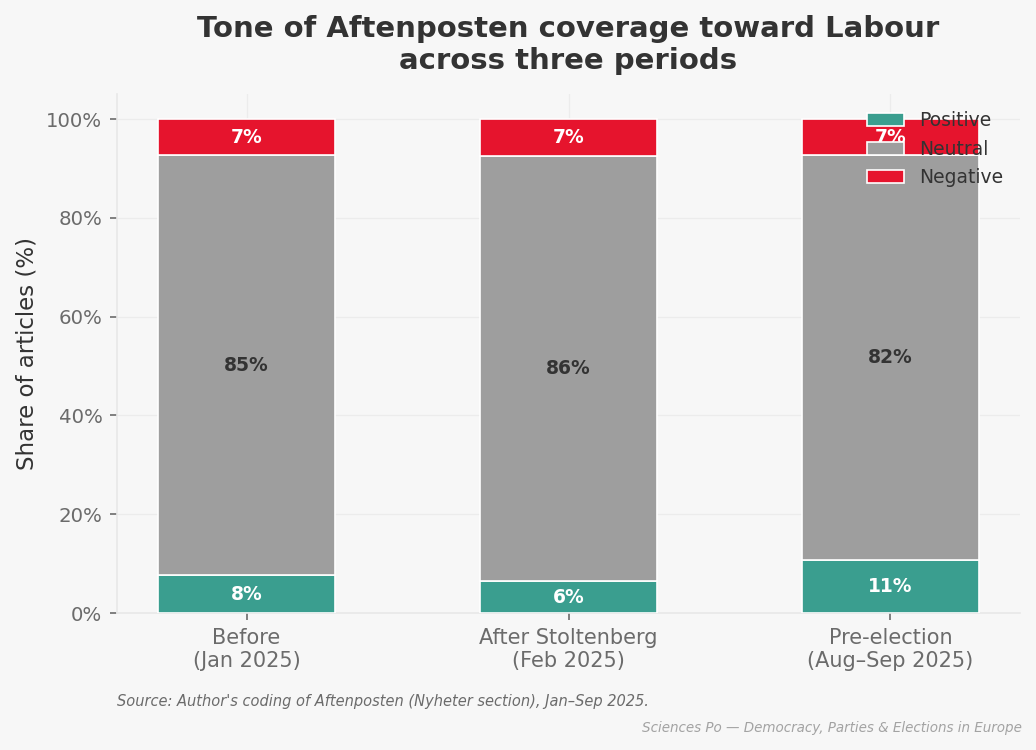

In [9]:
tone_order = ["POS", "NEU", "NEG"]
tone_cfg = {
    "POS": ("Positive", PAL["teal"]),
    "NEU": ("Neutral", PAL["grey"]),
    "NEG": ("Negative", SCPO_RED),
}

tone_pct = (
    pd.crosstab(dfa["tone_ap"], dfa["period"], normalize="columns")
    .reindex(index=tone_order, columns=PERIOD_ORDER)
    .fillna(0)
    * 100
)

fig, ax = plt.subplots(figsize=(7, 5))
bottom = np.zeros(len(PERIOD_ORDER))

for tone in tone_order:
    vals = np.array(
        [tone_pct.loc[tone, p] if tone in tone_pct.index else 0 for p in PERIOD_ORDER]
    )
    label, color = tone_cfg[tone]
    ax.bar(
        range(len(PERIOD_ORDER)),
        vals,
        bottom=bottom,
        label=label,
        color=color,
        edgecolor="white",
        linewidth=0.8,
        width=0.55,
        zorder=3,
    )
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(
                j,
                b + v / 2,
                f"{v:.0f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="white" if tone != "NEU" else SCPO_DARKGREY,
            )
    bottom += vals

ax.set_xticks(range(len(PERIOD_ORDER)))
ax.set_xticklabels([PERIOD_LABELS[p] for p in PERIOD_ORDER], fontsize=10)
ax.set_ylabel("Share of articles (%)")
ax.set_title("Tone of Aftenposten coverage toward Labour\nacross three periods", pad=12)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(loc="upper right")
add_source(ax)
add_watermark(fig)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig4_tone_labour.png")
fig.savefig(OUTPUT_DIR / "fig4_tone_labour.pdf")
plt.show()


## Figure 5 — The Repriming Slope Chart (paper-ready hero figure)


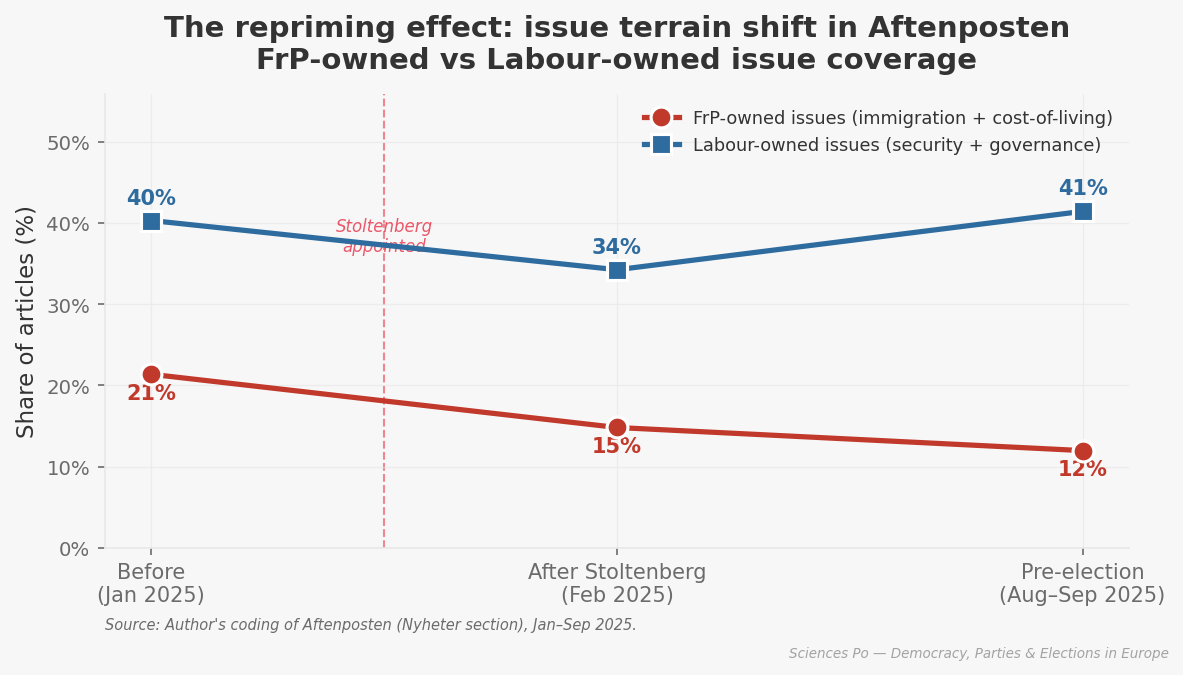

In [10]:
frp_vals = [
    group_pct.loc["FrP-owned", p] if "FrP-owned" in group_pct.index else 0
    for p in PERIOD_ORDER
]
lab_vals = [
    group_pct.loc["Labour-owned", p] if "Labour-owned" in group_pct.index else 0
    for p in PERIOD_ORDER
]
x = np.arange(len(PERIOD_ORDER))

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    x,
    frp_vals,
    "-o",
    color=GROUP_COLORS["FrP-owned"],
    linewidth=2.5,
    markersize=10,
    markeredgecolor="white",
    markeredgewidth=1.5,
    zorder=5,
    label="FrP-owned issues (immigration + cost-of-living)",
)
ax.plot(
    x,
    lab_vals,
    "-s",
    color=GROUP_COLORS["Labour-owned"],
    linewidth=2.5,
    markersize=10,
    markeredgecolor="white",
    markeredgewidth=1.5,
    zorder=5,
    label="Labour-owned issues (security + governance)",
)

for i, (fv, lv) in enumerate(zip(frp_vals, lab_vals)):
    off_f = 8 if fv >= lv else -12
    off_l = 8 if lv > fv else -12
    # Avoid overlap when values are close
    if abs(fv - lv) < 5:
        off_f, off_l = 10, -14
    ax.annotate(
        f"{fv:.0f}%",
        (x[i], fv),
        textcoords="offset points",
        xytext=(0, off_f),
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=GROUP_COLORS["FrP-owned"],
    )
    ax.annotate(
        f"{lv:.0f}%",
        (x[i], lv),
        textcoords="offset points",
        xytext=(0, off_l),
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=GROUP_COLORS["Labour-owned"],
    )

# Treatment marker
ax.axvline(x=0.5, color=SCPO_RED, linewidth=1, linestyle="--", alpha=0.5, zorder=1)
ax.text(
    0.5,
    ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 50,
    "Stoltenberg\nappointed",
    ha="center",
    va="top",
    fontsize=8,
    color=SCPO_RED,
    style="italic",
    alpha=0.7,
)

ax.set_xticks(x)
ax.set_xticklabels([PERIOD_LABELS[p] for p in PERIOD_ORDER], fontsize=10)
ax.set_ylabel("Share of articles (%)")
ax.set_title(
    "The repriming effect: issue terrain shift in Aftenposten\n"
    "FrP-owned vs Labour-owned issue coverage",
    pad=12,
)
ax.set_ylim(0, max(max(frp_vals), max(lab_vals)) * 1.35)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(loc="upper right", fontsize=8.5, framealpha=0.9)
add_source(ax)
add_watermark(fig)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig5_repriming_slope.png")
fig.savefig(OUTPUT_DIR / "fig5_repriming_slope.pdf")
plt.show()


## Figure 6 — Daily Issue Terrain (rolling average)

Day-by-day share of FrP-owned vs Labour-owned articles, with a 3-day rolling window to smooth daily noise.


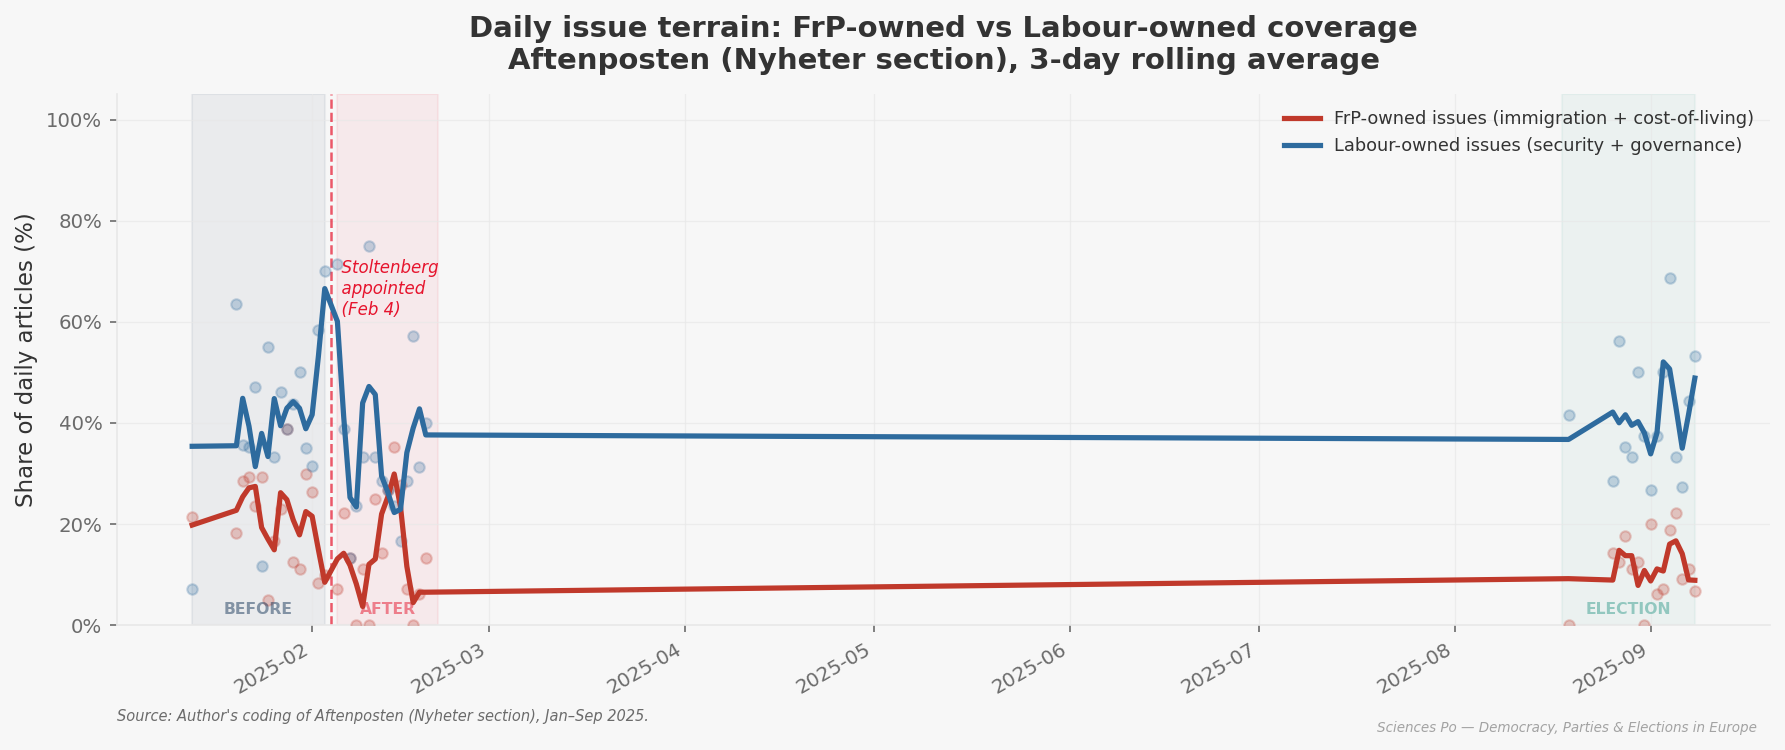

In [ ]:
# Constants needed for daily charts
ISSUE_COLORS = {
    "IMM": "#C0392B",
    "ECON": "#E67E22",
    "SEC": "#2E6B9E",
    "GOV": "#1B3A5C",
    "TAX": "#27AE60",
    "GAZ": "#8E44AD",
    "CLI": "#16A085",
    "HEA": "#D4707A",
    "OTH": "#BDC3C7",
}
WINDOW = 3  # rolling average window (days)

# Compute daily counts by issue group
daily = dfa.groupby(["date", "issue_group"]).size().unstack(fill_value=0)
daily_total = daily.sum(axis=1)

# Compute daily shares (%)
daily_pct = daily.div(daily_total, axis=0) * 100

# Ensure columns exist
for col in ["FrP-owned", "Labour-owned"]:
    if col not in daily_pct.columns:
        daily_pct[col] = 0.0

# Sort by date
daily_pct = daily_pct.sort_index()

# Rolling average (3-day window, centered)
WINDOW = 3
frp_roll = daily_pct["FrP-owned"].rolling(WINDOW, min_periods=1, center=True).mean()
lab_roll = daily_pct["Labour-owned"].rolling(WINDOW, min_periods=1, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 5))

# Raw daily dots
ax.scatter(
    daily_pct.index,
    daily_pct["FrP-owned"],
    color=GROUP_COLORS["FrP-owned"],
    alpha=0.25,
    s=25,
    zorder=3,
    label="_nolegend_",
)
ax.scatter(
    daily_pct.index,
    daily_pct["Labour-owned"],
    color=GROUP_COLORS["Labour-owned"],
    alpha=0.25,
    s=25,
    zorder=3,
    label="_nolegend_",
)

# Rolling lines
ax.plot(
    frp_roll.index,
    frp_roll.values,
    color=GROUP_COLORS["FrP-owned"],
    linewidth=2.5,
    zorder=4,
    label="FrP-owned issues (immigration + cost-of-living)",
)
ax.plot(
    lab_roll.index,
    lab_roll.values,
    color=GROUP_COLORS["Labour-owned"],
    linewidth=2.5,
    zorder=4,
    label="Labour-owned issues (security + governance)",
)

# Treatment line
ax.axvline(
    TREATMENT_DATE, color=SCPO_RED, linewidth=1.2, linestyle="--", alpha=0.7, zorder=2
)
ax.text(
    TREATMENT_DATE,
    ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] > 10 else 80,
    "  Stoltenberg\n  appointed\n  (Feb 4)",
    fontsize=8,
    color=SCPO_RED,
    style="italic",
    va="top",
)

# Period shading
for start, end, label, color in [
    (BEFORE_START, BEFORE_END, "BEFORE", PAL["blue_dark"]),
    (AFTER_START, AFTER_END, "AFTER", SCPO_RED),
    (ELECT_START, ELECT_END, "ELECTION", PAL["teal"]),
]:
    ax.axvspan(start, end, alpha=0.06, color=color, zorder=0)
    mid = start + (end - start) / 2
    ax.text(
        mid,
        ax.get_ylim()[1] * 0.02 if ax.get_ylim()[1] > 10 else 2,
        label,
        ha="center",
        va="bottom",
        fontsize=7.5,
        color=color,
        fontweight="bold",
        alpha=0.5,
    )

ax.set_ylabel("Share of daily articles (%)")
ax.set_title(
    "Daily issue terrain: FrP-owned vs Labour-owned coverage\n"
    f"Aftenposten (Nyheter section), {WINDOW}-day rolling average",
    pad=12,
)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_ylim(0, 105)
ax.legend(loc="upper right", fontsize=8.5)
fig.autofmt_xdate(rotation=30)
add_source(ax)
add_watermark(fig)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig6_daily_issue_terrain.png")
fig.savefig(OUTPUT_DIR / "fig6_daily_issue_terrain.pdf")
plt.show()

## Figure 7 — Daily article count by issue code (stacked area)

Shows the full issue landscape day by day as a stacked area chart.


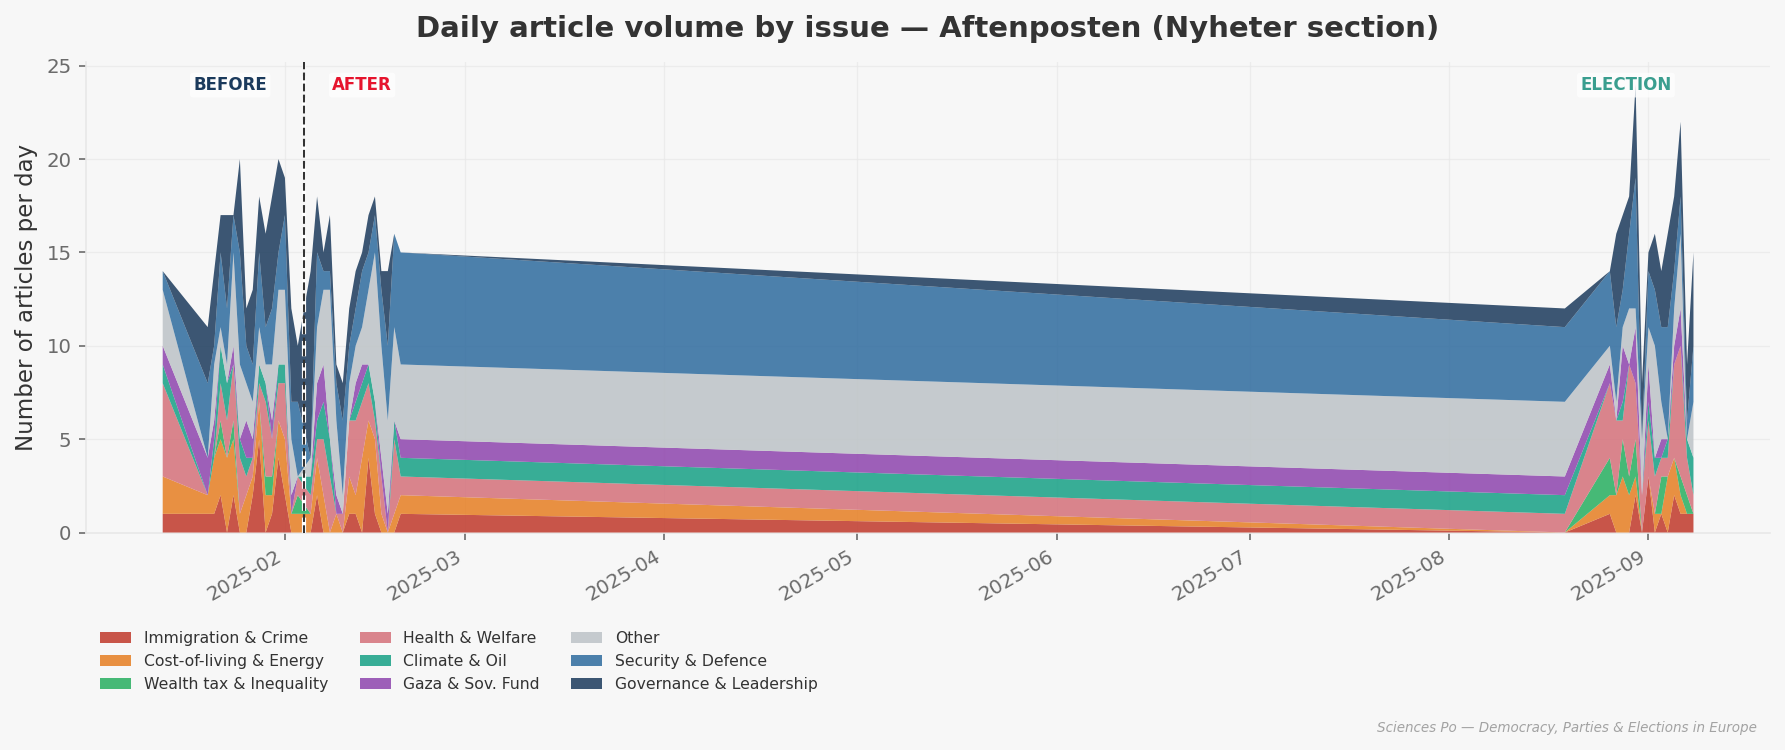

In [13]:
# Daily counts per issue code
daily_code = (
    dfa.groupby(["date", "issue_code"]).size().unstack(fill_value=0).sort_index()
)

# Reorder codes: FrP-owned at bottom, Labour-owned on top
code_order = ["IMM", "ECON", "TAX", "HEA", "CLI", "GAZ", "OTH", "SEC", "GOV"]
code_order = [c for c in code_order if c in daily_code.columns]

fig, ax = plt.subplots(figsize=(12, 5))

ax.stackplot(
    daily_code.index,
    *[daily_code[c].values for c in code_order],
    labels=[ISSUE_LABELS.get(c, c).replace("\n", " ") for c in code_order],
    colors=[ISSUE_COLORS.get(c, "#BDC3C7") for c in code_order],
    alpha=0.85,
    zorder=3,
)

# Treatment line
ax.axvline(TREATMENT_DATE, color="white", linewidth=2, linestyle="--", zorder=5)
ax.axvline(TREATMENT_DATE, color=SCPO_DARKGREY, linewidth=1, linestyle="--", zorder=5)

# Period shading labels
for start, end, label, color in [
    (BEFORE_START, BEFORE_END, "BEFORE", PAL["blue_dark"]),
    (AFTER_START, AFTER_END, "AFTER", SCPO_RED),
    (ELECT_START, ELECT_END, "ELECTION", PAL["teal"]),
]:
    mid = start + (end - start) / 2
    ax.text(
        mid,
        ax.get_ylim()[1] * 0.97 if ax.get_ylim()[1] > 5 else 5,
        label,
        ha="center",
        va="top",
        fontsize=8,
        color=color,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
    )

ax.set_ylabel("Number of articles per day")
ax.set_title("Daily article volume by issue — Aftenposten (Nyheter section)", pad=12)
ax.legend(
    loc="upper left", fontsize=7.5, ncol=3, bbox_to_anchor=(0, -0.18), frameon=False
)
fig.autofmt_xdate(rotation=30)
add_watermark(fig)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
fig.savefig(OUTPUT_DIR / "fig7_daily_stacked_area.png")
fig.savefig(OUTPUT_DIR / "fig7_daily_stacked_area.pdf")
plt.show()

## Figure 8 — Daily Stoltenberg mention rate

Tracks how often Stoltenberg appears in articles day by day, showing the "Stoltenberg saturation" of the news cycle.


In [ ]:
if "flag_stoltenberg" in dfa.columns:
    daily_stolt = dfa.groupby("date").agg(
        total=("flag_stoltenberg", "size"),
        stolt=("flag_stoltenberg", "sum"),
    )
    daily_stolt["pct"] = daily_stolt["stolt"] / daily_stolt["total"] * 100
    daily_stolt = daily_stolt.sort_index()
    stolt_roll = daily_stolt["pct"].rolling(WINDOW, min_periods=1, center=True).mean()

    fig, ax = plt.subplots(figsize=(12, 4))

    # Bar for raw daily %
    ax.bar(
        daily_stolt.index,
        daily_stolt["pct"],
        width=1.5,
        color=PAL["blue"],
        alpha=0.3,
        zorder=2,
        label="Daily %",
    )
    # Rolling line
    ax.plot(
        stolt_roll.index,
        stolt_roll.values,
        color=PAL["blue"],
        linewidth=2.5,
        zorder=4,
        label=f"{WINDOW}-day rolling average",
    )

    ax.axvline(
        TREATMENT_DATE,
        color=SCPO_RED,
        linewidth=1.2,
        linestyle="--",
        alpha=0.7,
        zorder=3,
    )
    ax.text(TREATMENT_DATE, 95, "  Feb 4", fontsize=8, color=SCPO_RED, style="italic")

    for start, end, color in [
        (BEFORE_START, BEFORE_END, PAL["blue_dark"]),
        (AFTER_START, AFTER_END, SCPO_RED),
        (ELECT_START, ELECT_END, PAL["teal"]),
    ]:
        ax.axvspan(start, end, alpha=0.06, color=color, zorder=0)

    ax.set_ylabel("% of articles mentioning Stoltenberg")
    ax.set_title("Stoltenberg in the news: daily mention rate in Aftenposten", pad=12)
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.legend(loc="upper right", fontsize=8.5)
    fig.autofmt_xdate(rotation=30)
    add_source(ax)
    add_watermark(fig)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig8_daily_stoltenberg.png")
    fig.savefig(OUTPUT_DIR / "fig8_daily_stoltenberg.pdf")
    plt.show()
else:
    print("⚠ flag_stoltenberg column not found — skipping Figure 8.")


## Summary table for the paper


In [11]:
full_cross = (
    pd.crosstab(dfa["issue_code"], dfa["period"])
    .reindex(columns=PERIOD_ORDER)
    .fillna(0)
    .astype(int)
)
full_pct = (
    pd.crosstab(dfa["issue_code"], dfa["period"], normalize="columns")
    .reindex(columns=PERIOD_ORDER)
    .fillna(0)
    * 100
)

table = pd.DataFrame()
for p in PERIOD_ORDER:
    table[f"{p} (n)"] = full_cross[p]
    table[f"{p} (%)"] = full_pct[p].round(1)

table["Δ BEFORE→AFTER (pp)"] = (
    full_pct.get("AFTER", 0) - full_pct.get("BEFORE", 0)
).round(1)
table["Δ BEFORE→ELEC (pp)"] = (
    full_pct.get("ELECTION", 0) - full_pct.get("BEFORE", 0)
).round(1)
table = table.sort_values("Δ BEFORE→AFTER (pp)", ascending=False)

# Totals
totals = {f"{p} (n)": full_cross[p].sum() for p in PERIOD_ORDER}
totals.update({f"{p} (%)": 100.0 for p in PERIOD_ORDER})
totals["Δ BEFORE→AFTER (pp)"] = 0
totals["Δ BEFORE→ELEC (pp)"] = 0
table.loc["TOTAL"] = totals

print("=" * 75)
print("TABLE — Issue distribution by period (Aftenposten, Nyheter)")
print("=" * 75)
print(table.to_string())

# Issue groups
grp = group_pct.copy()
grp["Δ BEFORE→AFTER"] = (grp["AFTER"] - grp["BEFORE"]).round(1)
grp["Δ BEFORE→ELEC"] = (grp["ELECTION"] - grp["BEFORE"]).round(1)

print("\n" + "=" * 75)
print("ISSUE GROUPS — Hypothesis test")
print("=" * 75)
print(grp.round(1).to_string())
print("\n→ H1: Labour-owned should INCREASE after appointment")
print("→ H2: FrP-owned should DECREASE after appointment")

table.to_csv(OUTPUT_DIR / "table_issue_distribution.csv")
grp.to_csv(OUTPUT_DIR / "table_issue_groups.csv")
print(f"\nAll figures and tables saved to {OUTPUT_DIR}/")


TABLE — Issue distribution by period (Aftenposten, Nyheter)
            BEFORE (n)  BEFORE (%)  AFTER (n)  AFTER (%)  ELECTION (n)  ELECTION (%)  Δ BEFORE→AFTER (pp)  Δ BEFORE→ELEC (pp)
issue_code                                                                                                                   
OTH                 38        15.3         59       27.3            33          14.1                 12.0                -1.2
HEA                 30        12.1         29       13.4            43          18.4                  1.3                 6.3
CLI                 12         4.8         12        5.6             8           3.4                  0.7                -1.4
GAZ                 10         4.0         10        4.6            14           6.0                  0.6                 2.0
SEC                 46        18.5         41       19.0            49          20.9                  0.4                 2.4
TAX                  5         2.0          0        0.0  